<a href="https://colab.research.google.com/github/carl-wanninger/open-mod-2026/blob/main/assume_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
# Remove tensorflow from colabs environment as it leads to version conflict.
!pip uninstall -y tensorflow

# Clone workshop branch from assume repository.
!rm -r repo_assume/
!git clone -b open-mod-09-26 --depth=1 https://github.com/assume-framework/assume.git repo_assume

# Install packages. Colab raises (non-critical) dependency conflicts.
!pip install -e "./repo_assume[colab,learning]"

Cloning into 'repo_assume'...
remote: Enumerating objects: 459, done.
remote: Counting objects: 100% (459/459), done.
remote: Compressing objects: 100% (396/396), done.
remote: Total 459 (delta 113), reused 206 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (459/459), 15.77 MiB | 9.56 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Obtaining file:///content/repo_assume
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for assume-framework (pyproject.toml) ... done
  Created wheel for assume-framework: filename=assume_framework-0.1.dev1+g23f79a300-0.editable-py3-none-any.whl size=20398 sha256=622983316454a59ddcc5e24b0fc27242411753a699bbb361e6c28c77e6d3b96d
  Stored in directory: /tmp/pip-ephem-wheel-cache-u9s_r6nd/wheels/d4/47/4d/bba546fa7eb6a724a1f3a2ea4f4e845186f558cec34951c00a
Successfully bu

In [ ]:
# Imports and most crucial paths.
import pandas as pd
from pathlib import Path
import yaml

import sys

# Append the directory containing your package
sys.path.append("/content/repo_assume/")

from assume.common.forecaster import PowerplantForecaster
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from assume.workshop import plot

output_dir = Path("")
inputs_path = "/content/repo_assume/examples/inputs"

config_file = Path(inputs_path) / "workshop-openmod" / "config.yaml"

if not Path("./examples/local_db").exists():
  Path("./examples/local_db").mkdir(parents=True)


# Study case 1: Gas plant bids marginal costs.
Other market participants are a low-marginal nuclear power plant and a high-marginal backup gas plant.


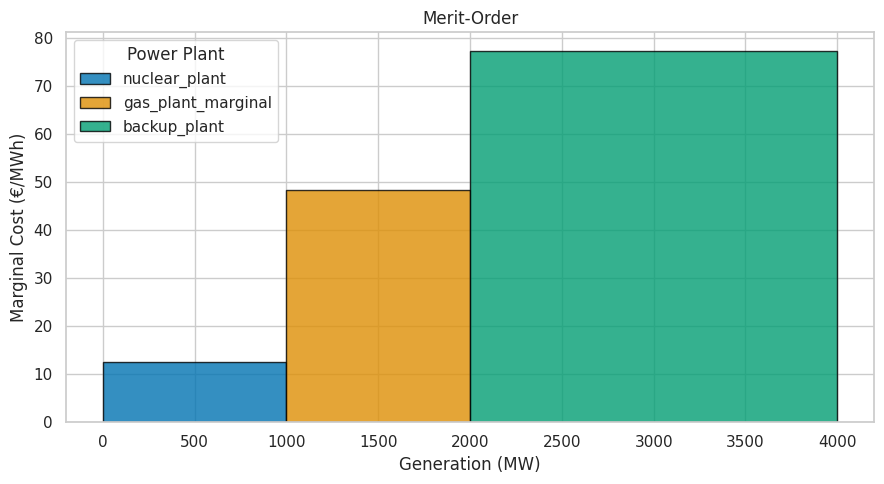

In [ ]:
# We calculate marginal costs to display merit order.

powerplants_path = Path(inputs_path + "/workshop-openmod/powerplant_units_study_1.csv")
power_plants_df = pd.read_csv(powerplants_path)

fuel_price_path = Path(inputs_path + "/workshop-openmod") / "fuel_prices_df.csv"
fuel_price_df = pd.read_csv(fuel_price_path)

fuel_prices = power_plants_df["fuel_type"].map(lambda x: fuel_price_df[x].iloc[0])
marginal_costs = power_plants_df["additional_cost"] + (fuel_prices / power_plants_df["efficiency"])
power_plants_df["marginal_costs"] = marginal_costs

fig, ax = plot.plot_merit_order(power_plants_df)

Demand is low during night time.

                datetime  demand_EOM
5668 2019-03-01 01:00:00      992.72
5669 2019-03-01 01:15:00      985.36
5670 2019-03-01 01:30:00      982.80
5671 2019-03-01 01:45:00      975.68
5672 2019-03-01 02:00:00      967.60


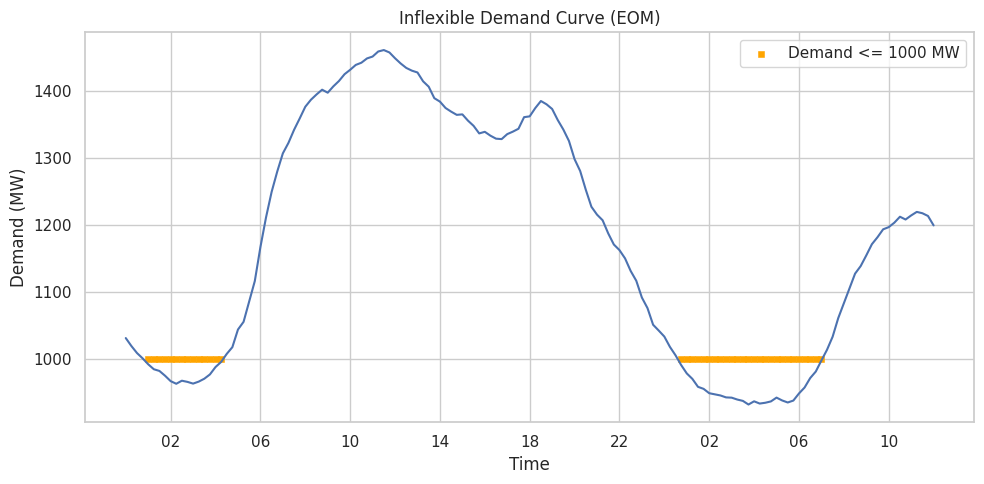

In [ ]:
with config_file.open() as fp:
    config = yaml.safe_load(fp)

demand_file = Path(inputs_path + "/workshop-openmod") / "demand_df.csv"
demand_df = pd.read_csv(demand_file, parse_dates=["datetime"])

# Demand df is for full year. We project it to investigated time.
start_time = config["marginal"]["start_date"]
end_time = config["marginal"]["end_date"]

plot_df = demand_df[demand_df["datetime"] >= start_time]
plot_df = plot_df[plot_df["datetime"] <= end_time]

fig, ax = plot.plot_demand(plot_df)

# Study case 1: Gas plant bids marginal costs.
Other market participants are a low-marginal nuclear power plant and a high-marginal backup gas plant.

In [ ]:
world = World(
    database_uri="",
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "marginal")

world.run()

INFO:assume.common.utils:Downsampling /content/repo_assume/examples/inputs/workshop-openmod/demand_df.csv successful.
workshop-openmod_marginal 2019-03-02 11:00:00:  97%|█████████▋| 126001/129600 [00:00<00:00, 922571.01it/s]


Market orders will be accepted when demand is larger than 1000 MW.

Text(0.5, 1.0, 'Accepted Volume (Power Plants, Study Case 1)')

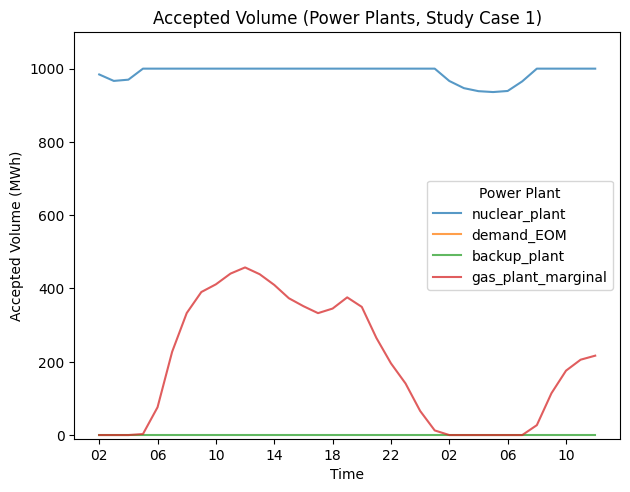

In [ ]:
market_orders = pd.read_csv(Path(output_dir) / "workshop-openmod_marginal"  / "market_orders.csv")
fig, ax = plot.plot_accepted_volume(market_orders)
ax.set_title("Accepted Volume (Power Plants, Study Case 1)")


## Study case 2: Gas plant learns its bidding behavior.
As before there is nuclear and backup generation.

In [ ]:
%%capture
# surpress output.

db_uri = "sqlite:///./examples/local_db/assume_db_learning.db"


with config_file.open() as fp:
    config = yaml.safe_load(fp)

config["learning"]["learning_config"]["training_episodes"] = 10
config["learning"]["learning_config"]["learning_rate"] = 0.002
config["learning"]["learning_config"]["gradient_steps"] = 64
config["learning"]["learning_config"]["train_freq"] = "6h"
config["learning"]["bidding_strategy_params"] = {"foresight": 1}

with config_file.open('w') as fp:
    yaml.safe_dump(config, fp, indent=4, default_flow_style=False)

world = World(
    database_uri=db_uri,
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "learning")

run_learning(world)
world.run()

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: /content/repo_assume/examples/inputs/workshop-openmod
INFO:assume.scenario.loader_csv:Study case: learning
INFO:assume.scenario.loader_csv:Simulation ID: workshop-openmod_learning
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/unit_operators.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/storage_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/exchange_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/industrial_dsm_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/residential_dsm_units.csv not found. Returning None
INFO:assume.common.utils:Downsampling /content/repo_assume/

Accepted volume does not change for learning gas plant.

Text(0.5, 1.0, 'Accepted Volume (Power Plants, Study Case 2)')

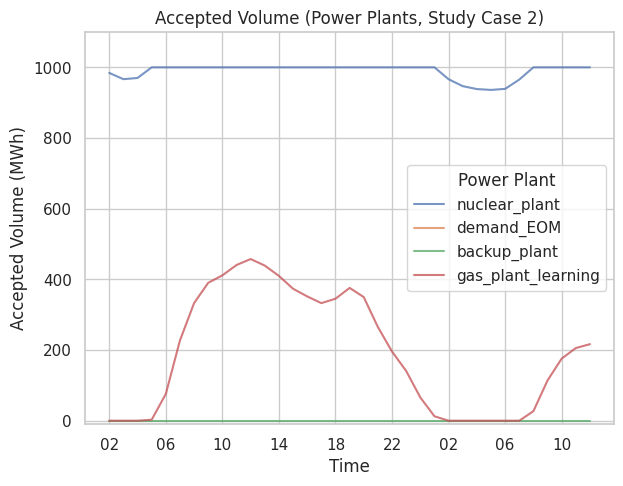

In [ ]:
market_orders = pd.read_csv(Path(output_dir) / "workshop-openmod_learning"  / "market_orders.csv")
market_orders.head()

fig, ax = plot.plot_accepted_volume(market_orders)
ax.set_title("Accepted Volume (Power Plants, Study Case 2)")


Accepted volume does not change between study cases. But what about revenue?

Text(0.5, 1.0, 'Offer price: Case 1 vs. Case 2')

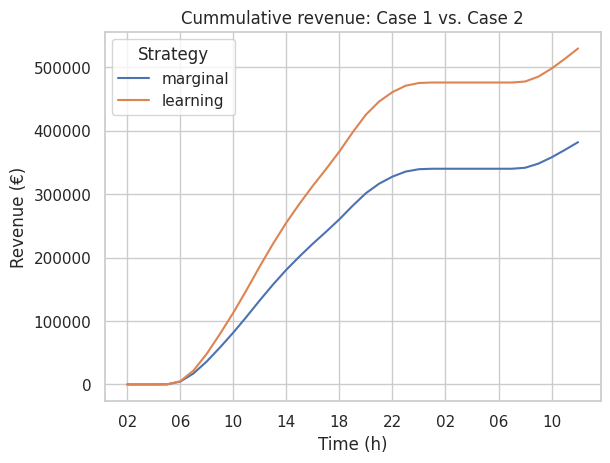

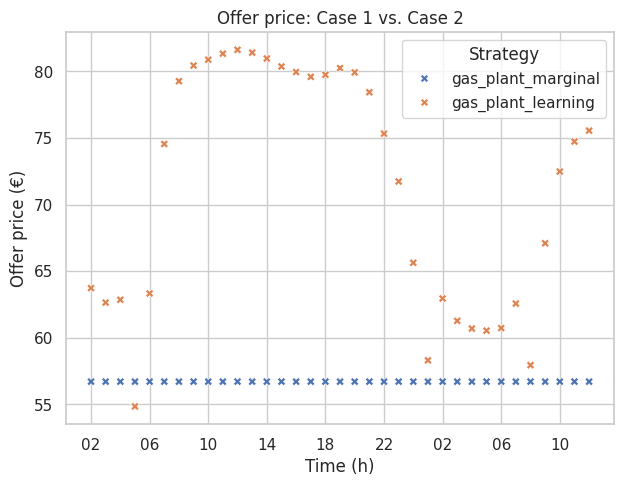

In [ ]:
p1 = Path("/content/workshop-openmod_marginal/market_orders.csv")
p2 = Path("/content/workshop-openmod_learning/market_orders.csv")

df1 = pd.read_csv(p1).query("unit_id == 'gas_plant_marginal'")
df2 = pd.read_csv(p2).query("unit_id == 'gas_plant_learning'")

df1["strategy"] = "marginal"
df2["strategy"] = "learning"
df = pd.concat([df1, df2])

fig, ax = plot.plot_revenue(df)
ax.set_title("Cummulative revenue: Case 1 vs. Case 2")

fig, ax = plot.plot_biddings(df)
ax.set_title("Offer price: Case 1 vs. Case 2")

# Study case 3: Two learning gas plants - no nuclear plant.
Backup generation is still there.

In [ ]:
%%capture
# Surpress output. This cell will take ~ 2 minutes.


db_uri = "sqlite:///./examples/local_db/assume_db_learning.db"


with config_file.open() as fp:
    config = yaml.safe_load(fp)

config["learning_2_agents"]["learning_config"]["training_episodes"] = 25
config["learning_2_agents"]["learning_config"]["learning_rate"] = 0.001
config["learning_2_agents"]["learning_config"]["gradient_steps"] = 64
config["learning_2_agents"]["learning_config"]["train_freq"] = "5h"
config["learning_2_agents"]["bidding_strategy_params"] = {"foresight": 1}

with config_file.open('w') as fp:
    yaml.safe_dump(config, fp, indent=4, default_flow_style=False)

world = World(
    database_uri=db_uri,
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "learning_2_agents")

run_learning(world)
world.run()



INFO:assume.world:Connected to the database
INFO:assume.common.utils:Downsampling /content/repo_assume/examples/inputs/workshop-openmod/demand_df.csv successful.


Do you want to overwrite and start fresh? (y/N) y


INFO:assume.common.utils:Previous strategies at '/content/repo_assume/examples/inputs/workshop-openmod/learned_strategies/workshop-openmod_learning_2_agents' deleted. Starting fresh training.
INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 1, metric='avg_reward', value=1.23
INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 2, metric='avg_reward', value=1.97
INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 3, metric='avg_reward', value=1.43
INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 4, metric='avg_reward', value=1.01


In [1]:
path_market_orders = Path("workshop-openmod_learning_2_agents/market_orders.csv")
market_orders_df = pd.read_csv(path_market_orders)

plot_df = market_orders_df[market_orders_df["unit_id"].str.contains("plant")]

plot_df["strategy"] = plot_df["unit_id"]

fig, ax = plot.plot_revenue(plot_df)
ax.set_title("Cummulative revenue: Agent 1 vs. Agent 2")

fig, ax = plot.plot_biddings_with_clearing_price(plot_df)
ax.set_title("Offer prices: Agent 1 vs. Agent 2")

NameError: name 'Path' is not defined